# MiniGrid VLM Benchmark — Results Analysis

In [59]:
RESULTS_DIR = "./results_izar"    # folder that contains raw/ and benchmark_results.csv
IMAGE_DIR = "./dataset/"  # folder that contains the original environment screenshots (for visualization)

MODEL_ORDER   = ["qwen3b", "qwen7b", "internvl", "smolvlm"]
VARIANT_ORDER = ["if_then", "negative_rules", "verbose"] # These are different type of prompts tested
ACTION_ORDER  = ["turn_left", "turn_right", "forward", "pickup", "toggle"]

In [60]:
import json
import ast
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
sns.set_style("whitegrid")

## 0. Presentation of dataset

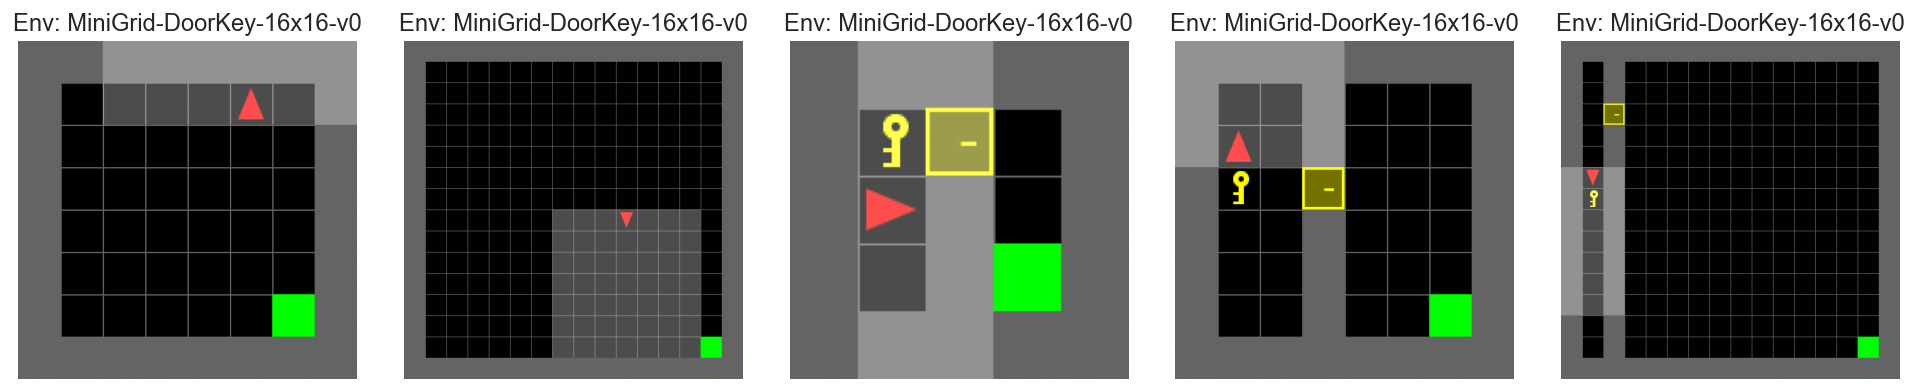

In [61]:
# Show an example of each images of the different environments
df = pd.read_csv(Path(RESULTS_DIR) / "benchmark_results.csv")

imgs_id_to_show = []
already_seen_envs = set()
for env in df["env"].unique():
    with open("./dataset/dataset.json") as f:
        dataset = json.load(f)
    for env_data in dataset:
        if env_data["env"] == env and env not in already_seen_envs:
            imgs_id_to_show.append(env_data["global_image"])
            already_seen_envs.add(env)

fig, axs = plt.subplots(1, len(imgs_id_to_show), figsize=(15, 3))
for i, img_id in enumerate(imgs_id_to_show):
    img_path = Path(IMAGE_DIR) / f"{img_id}"
    img = plt.imread(img_path)
    axs[i].imshow(img)
    axs[i].set_title(f"Env: {df[df['env'] == env]['env'].iloc[0]}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

In [78]:
# Show an example of the different prompts we used

from run_benchmark import PROMPT_VARIANTS

# Dummy state for illustration
dummy_state = {
    "mission": "pick up the key and open the door to reach the goal",
    "agent_dir_str": "right",
    "agent_carrying": "key",
}

for prompt_variant in PROMPT_VARIANTS:
    for view in ["global"]:
        print("=" * 80)
        print(f"Variant: {prompt_variant['name']} | View: {view} | ~{prompt_variant['approx_tokens']} tokens")
        print("=" * 80)
        prompt = prompt_variant["fn"](dummy_state, view)
        print(prompt)
        print()

Variant: if_then | View: global | ~170 tokens
Grid navigation. Agent faces right. Mission: pick up the key and open the door to reach the goal
You are currently carrying a key.

Decision rules (apply the first that matches):
  → If the GREEN GOAL is directly right: action 2 (forward)
  → If a KEY is directly right and you need it: action 3 (pickup)
  → If a DOOR is directly right and you have the key: action 5 (toggle)
  → If turning right gets you closer to your target: action 1
  → If turning left gets you closer to your target: action 0
  → Otherwise move forward: action 2

Based on the image, which action applies? YOU HAVE TO REPLY WITH ONE INTEGER ONLY.

Variant: negative_rules | View: global | ~180 tokens
Grid agent (red triangle) faces right. You carry a key.
Mission: pick up the key and open the door to reach the goal

Rules:
  ✗ Do NOT pick up (action 3) unless a key is DIRECTLY right of you.
  ✗ Do NOT toggle (action 5) unless a door is DIRECTLY right of you AND you hold the 

## 1. Overall accuracy

In [62]:
df = pd.read_csv(Path(RESULTS_DIR) / "benchmark_results.csv")

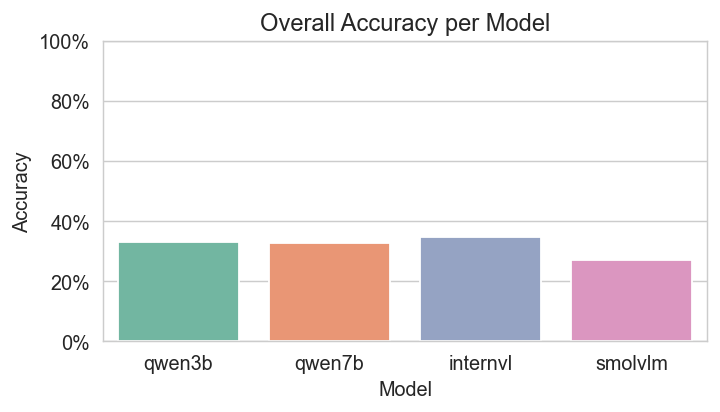

In [63]:
# 1. Accuracy per model: 

acc_per_model = df.groupby("model")["correct"].mean().reindex(MODEL_ORDER)
plt.figure(figsize=(6,3))
sns.barplot(x=acc_per_model.index, y=acc_per_model.values, palette="Set2", errorbar=("ci",95))
plt.ylim(0, 1)
plt.title("Overall Accuracy per Model")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

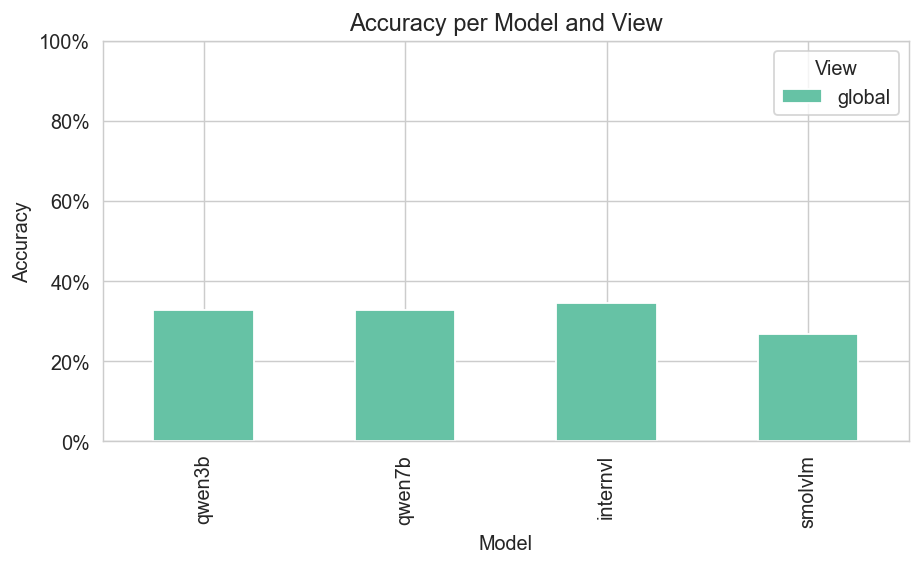

In [64]:
# 2. Accuracy per model and per view, if one of the view is not available, it will be set to 0.
acc_per_model_view = df.groupby(["model", "view"])["correct"].mean().unstack().reindex(MODEL_ORDER)
acc_per_model_view = acc_per_model_view.fillna(0)  # Set missing views to 0 accuracy
acc_per_model_view.plot(kind="bar", figsize=(8,4), color=sns.color_palette("Set2"))
plt.ylim(0, 1)
plt.title("Accuracy per Model and View")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(title="View")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

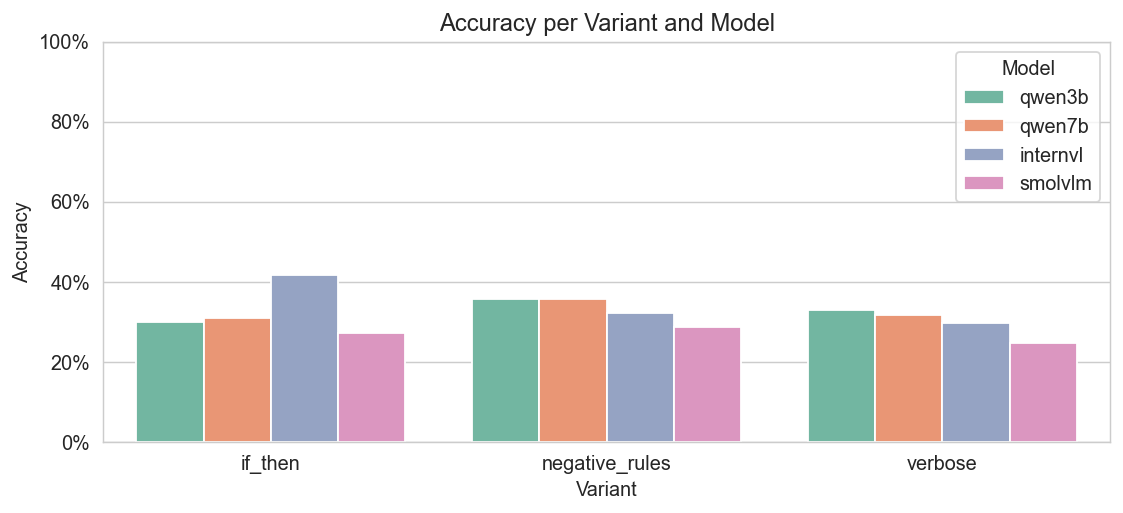

In [65]:
# 3. Accuracy per variant and per model:
acc_per_variant = df.groupby(["variant", "model"])["correct"].mean().reindex(
    pd.MultiIndex.from_product([VARIANT_ORDER, MODEL_ORDER])
)
plt.figure(figsize=(10,4))
sns.barplot(x=acc_per_variant.index.get_level_values(0), y=acc_per_variant.values, hue=acc_per_variant.index.get_level_values(1), palette="Set2")
plt.ylim(0, 1)
plt.title("Accuracy per Variant and Model")
plt.ylabel("Accuracy")
plt.xlabel("Variant")
plt.legend(title="Model")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()


## 3. Comparison on the different environments

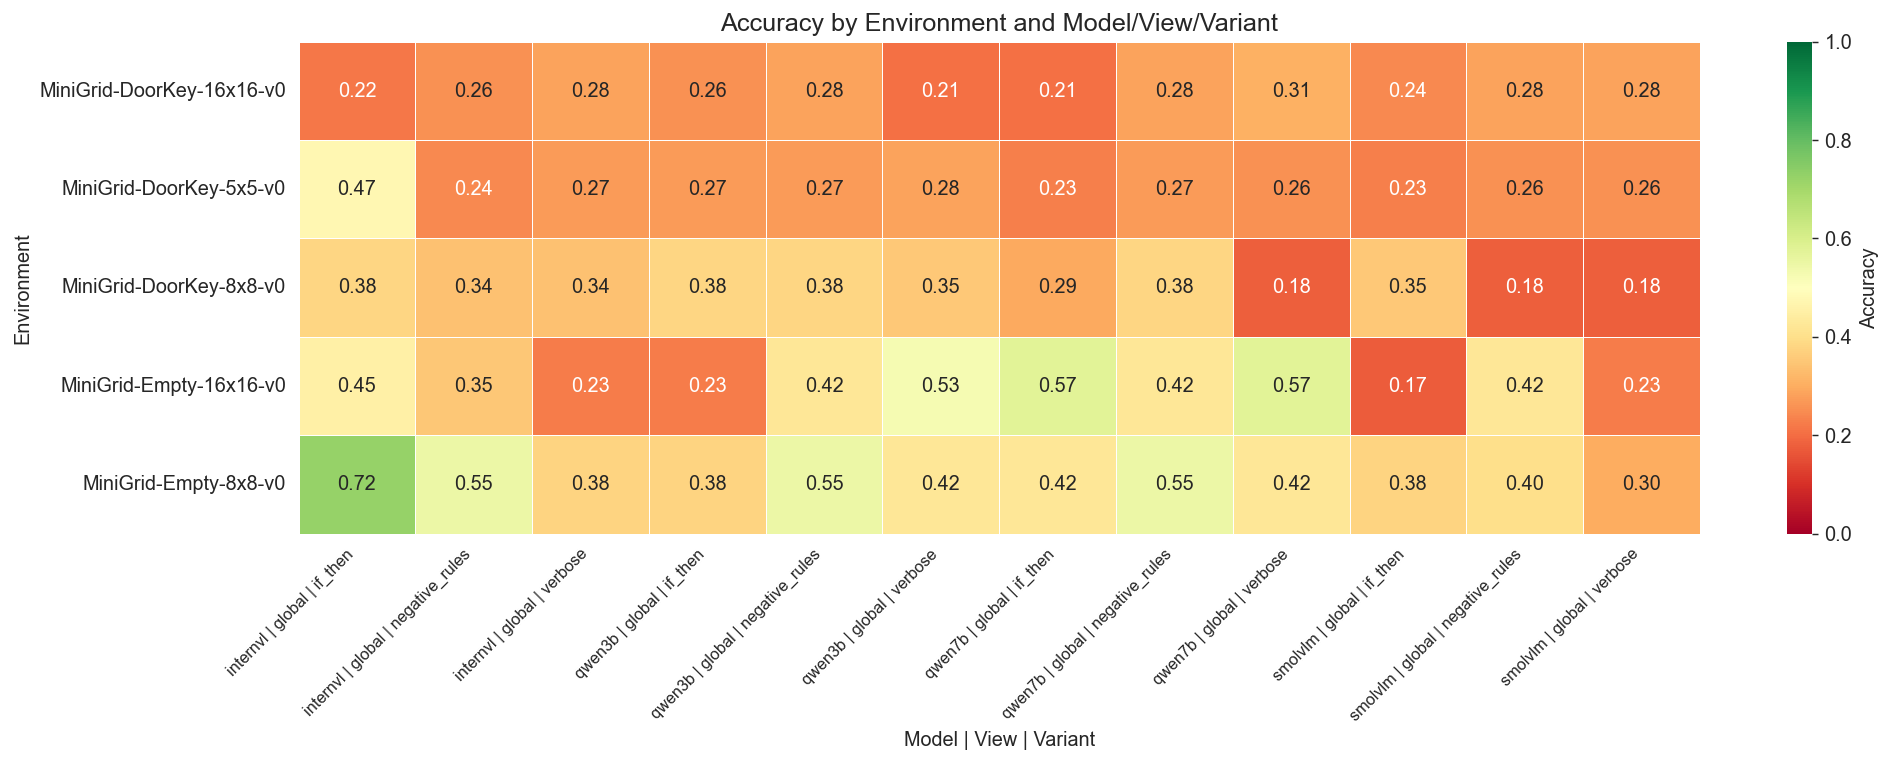

In [66]:
# 4. Compare the accuracy of each different models, ie model_view_variant combinations across 'env'
acc_per_model_view_variant = df.groupby(["model", "view", "variant", "env"])["correct"].mean().reset_index()

# Create a combined label for the x-axis
acc_per_model_view_variant["model_view_variant"] = (
    acc_per_model_view_variant["model"] + " | " +
    acc_per_model_view_variant["view"] + " | " +
    acc_per_model_view_variant["variant"]
)

# Pivot for heatmap format
heatmap_data = acc_per_model_view_variant.pivot(
    index="env",
    columns="model_view_variant",
    values="correct"
)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Accuracy"}
)

ax.set_title("Accuracy by Environment and Model/View/Variant", fontsize=14)
ax.set_xlabel("Model | View | Variant", fontsize=11)
ax.set_ylabel("Environment", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Correspondance between env and complexity:
  MiniGrid-Empty-8x8-v0 → simple
  MiniGrid-Empty-16x16-v0 → simple
  MiniGrid-DoorKey-5x5-v0 → medium
  MiniGrid-DoorKey-8x8-v0 → medium
  MiniGrid-DoorKey-16x16-v0 → hard


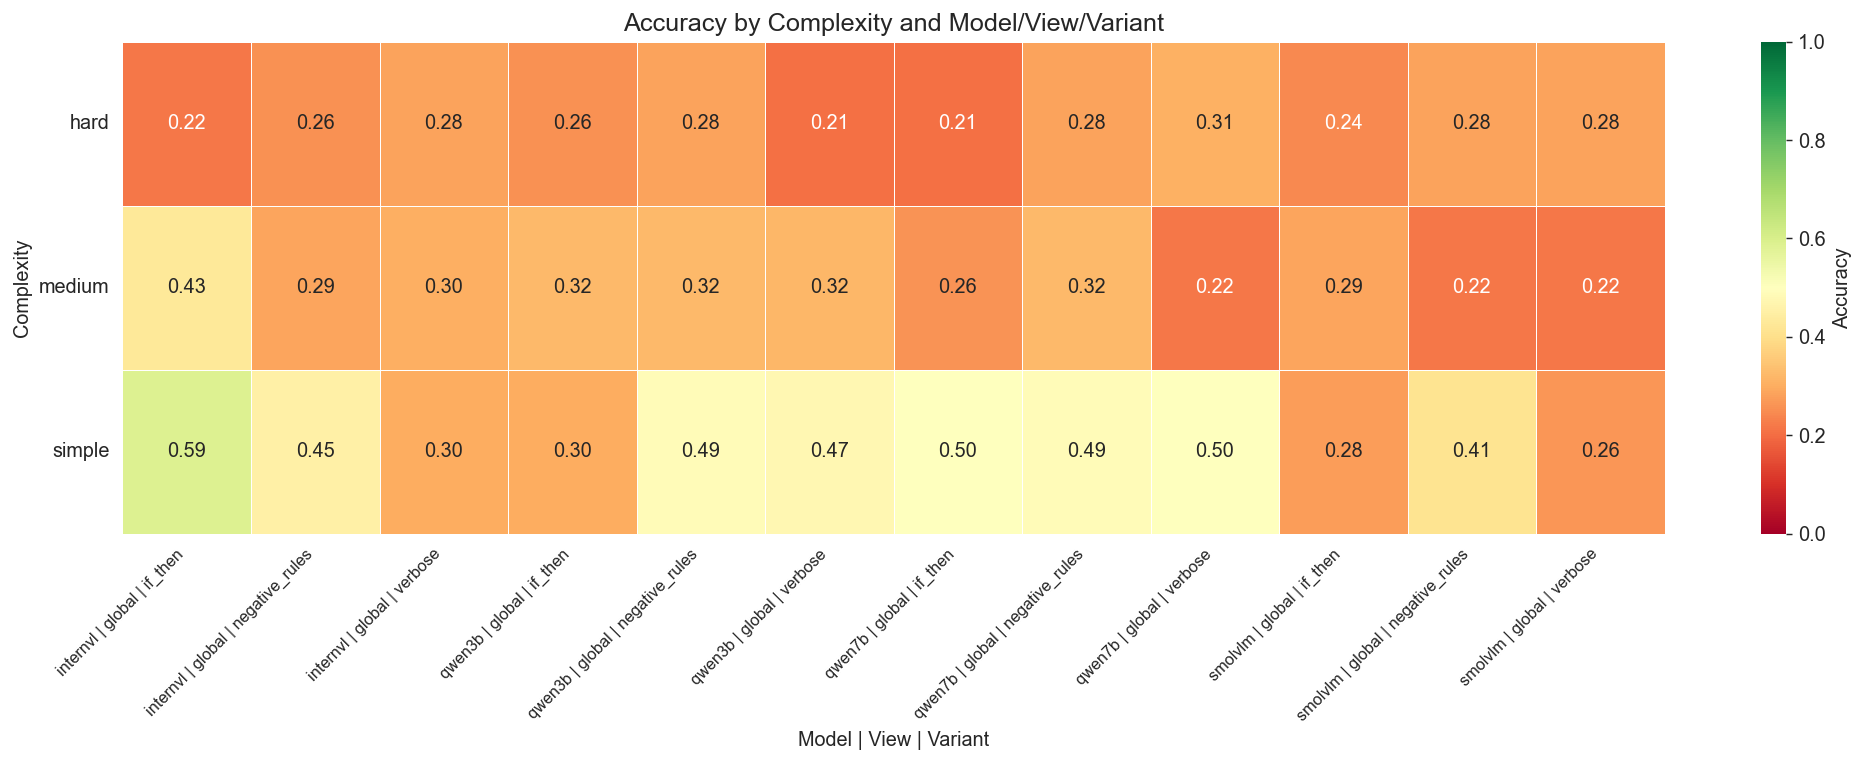

In [67]:
# 5. Same as above but using complexity instead of env
print("Correspondance between env and complexity:")
for env, complexity in df[["env", "complexity"]].drop_duplicates().values:
    print(f"  {env} → {complexity}")


acc_per_model_view_variant_complexity = df.groupby(["model", "view", "variant", "complexity"])["correct"].mean().reset_index()
acc_per_model_view_variant_complexity["model_view_variant"] = (
    acc_per_model_view_variant_complexity["model"] + " | " +
    acc_per_model_view_variant_complexity["view"] + " | " +
    acc_per_model_view_variant_complexity["variant"]
)
heatmap_data_complexity = acc_per_model_view_variant_complexity.pivot(
    index="complexity",
    columns="model_view_variant",
    values="correct"
)
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    heatmap_data_complexity,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Accuracy"}
)
ax.set_title("Accuracy by Complexity and Model/View/Variant", fontsize=14)
ax.set_xlabel("Model | View | Variant", fontsize=11)
ax.set_ylabel("Complexity", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 4. What does each model predict when wrong?

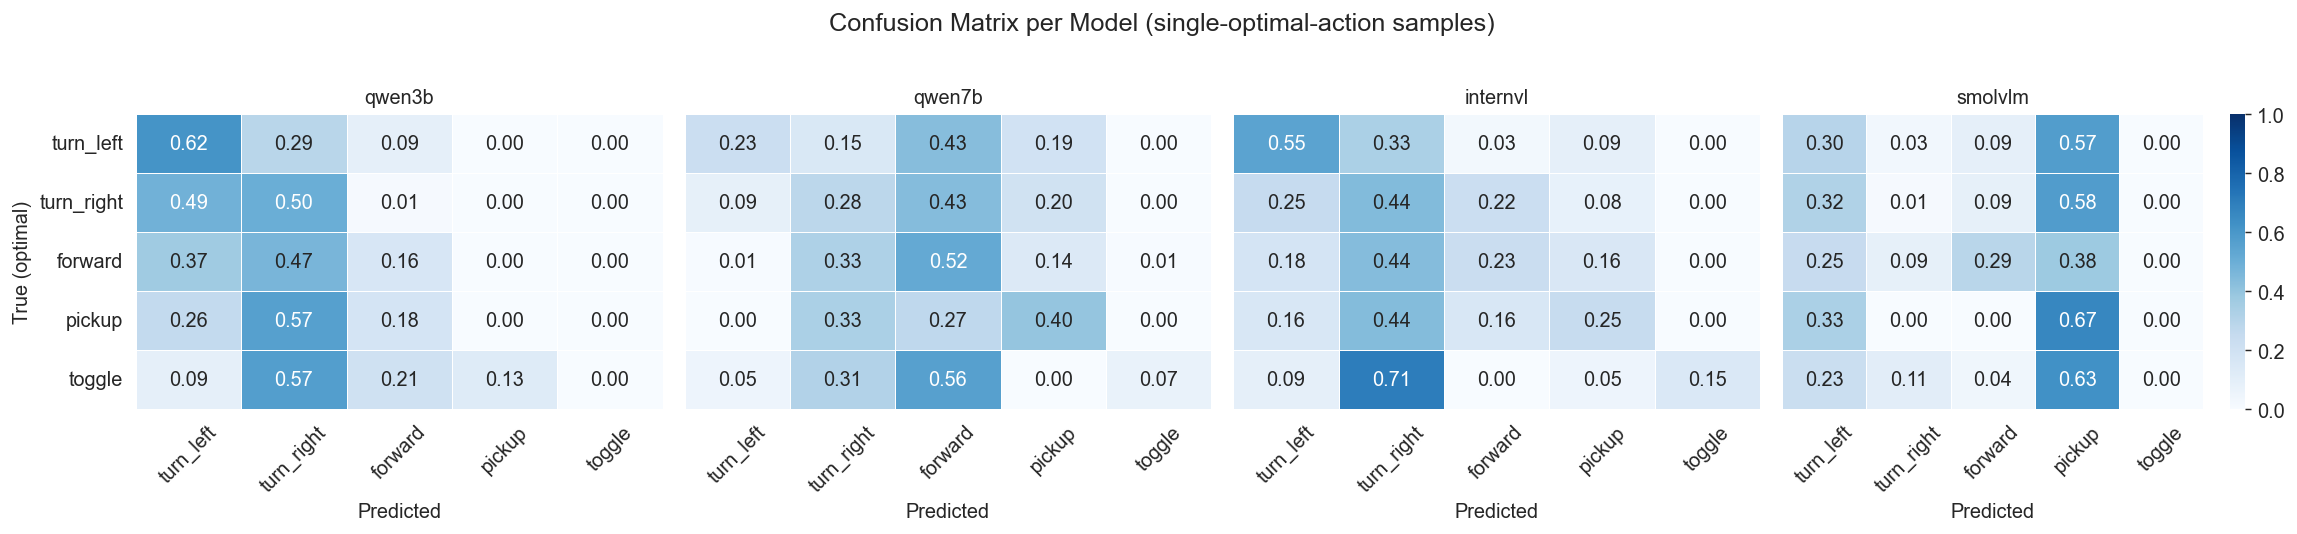

In [68]:
ACTION_MAP = {0: "turn_left", 1: "turn_right", 2: "forward", 3: "pickup", 5: "toggle"}
ACTION_LABELS = ["turn_left", "turn_right", "forward", "pickup", "toggle"]
ACTION_INDICES = [0, 1, 2, 3, 5]

import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only rows with a single optimal action (unambiguous ground truth for confusion matrix)
df["opt_list"] = df["optimal_actions"].apply(ast.literal_eval)
df_single = df[df["opt_list"].apply(len) == 1].copy()
df_single["optimal_action"] = df_single["opt_list"].apply(lambda x: x[0])

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(18, 4), sharey=True)
fig.suptitle("Confusion Matrix per Model (single-optimal-action samples)", fontsize=14, y=1.02)

for ax, model in zip(axes, MODEL_ORDER):
    sub = df_single[df_single["model"] == model]
    # Build confusion matrix
    cm = np.zeros((len(ACTION_INDICES), len(ACTION_INDICES)), dtype=int)
    for _, row in sub.iterrows():
        true_idx = ACTION_INDICES.index(row["optimal_action"])
        pred_val = int(row["predicted_action"])
        if pred_val in ACTION_INDICES:
            pred_idx = ACTION_INDICES.index(pred_val)
            cm[true_idx, pred_idx] += 1

    # Normalize by row (true label)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm / row_sums, 0)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=ACTION_LABELS,
        yticklabels=ACTION_LABELS,
        ax=ax,
        cbar=(ax == axes[-1]),
        linewidths=0.4,
    )
    ax.set_title(model, fontsize=11)
    ax.set_xlabel("Predicted")
    if ax == axes[0]:
        ax.set_ylabel("True (optimal)")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


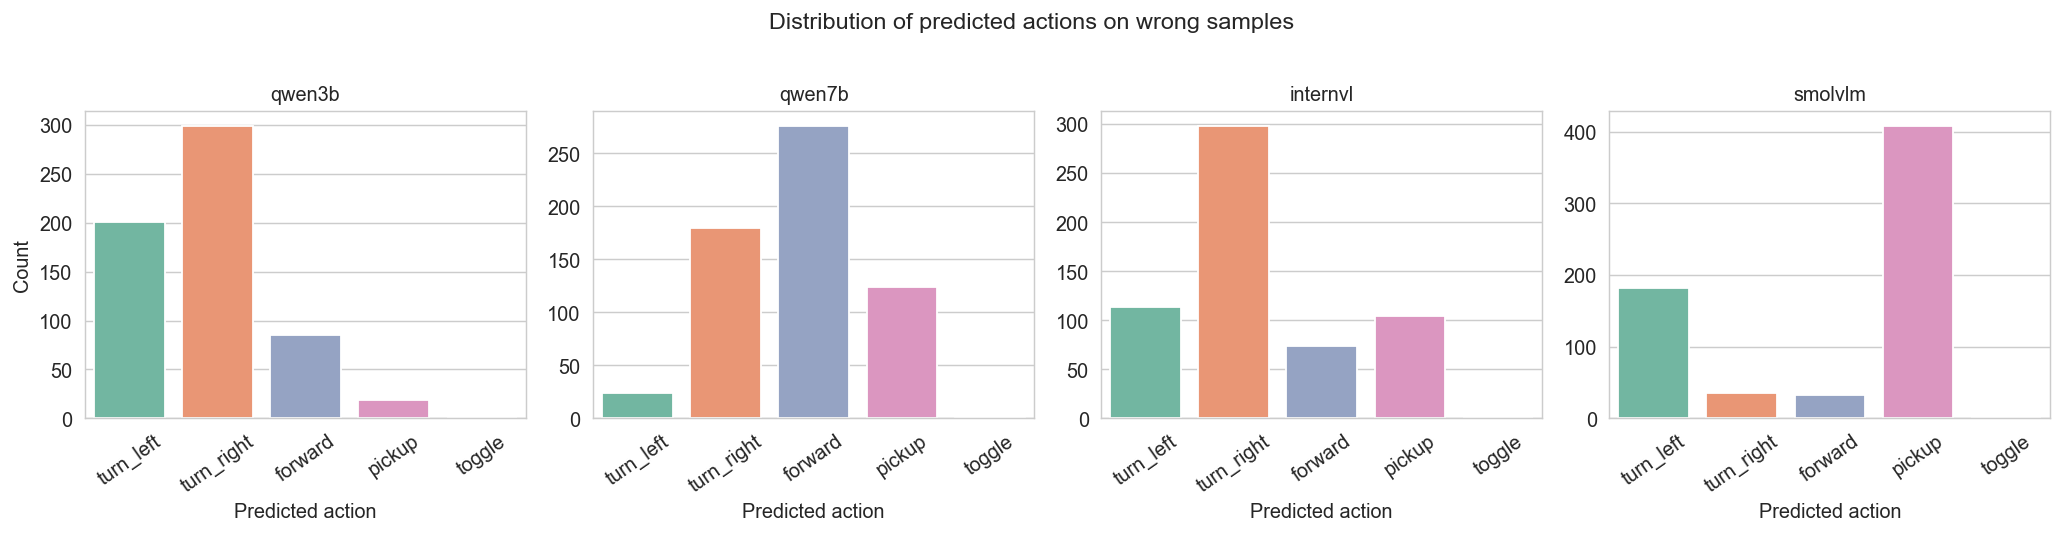

In [69]:
# When wrong, what action does each model predict? (absolute counts)
wrong = df[df["correct"] == False].copy()
wrong["predicted_label"] = wrong["predicted_action"].map(ACTION_MAP)

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(16, 4), sharey=False)
fig.suptitle("Distribution of predicted actions on wrong samples", fontsize=13, y=1.02)

for ax, model in zip(axes, MODEL_ORDER):
    sub = wrong[wrong["model"] == model]
    counts = sub["predicted_label"].value_counts().reindex(ACTION_LABELS, fill_value=0)
    sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
    ax.set_title(model, fontsize=11)
    ax.set_xlabel("Predicted action")
    ax.set_ylabel("Count" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


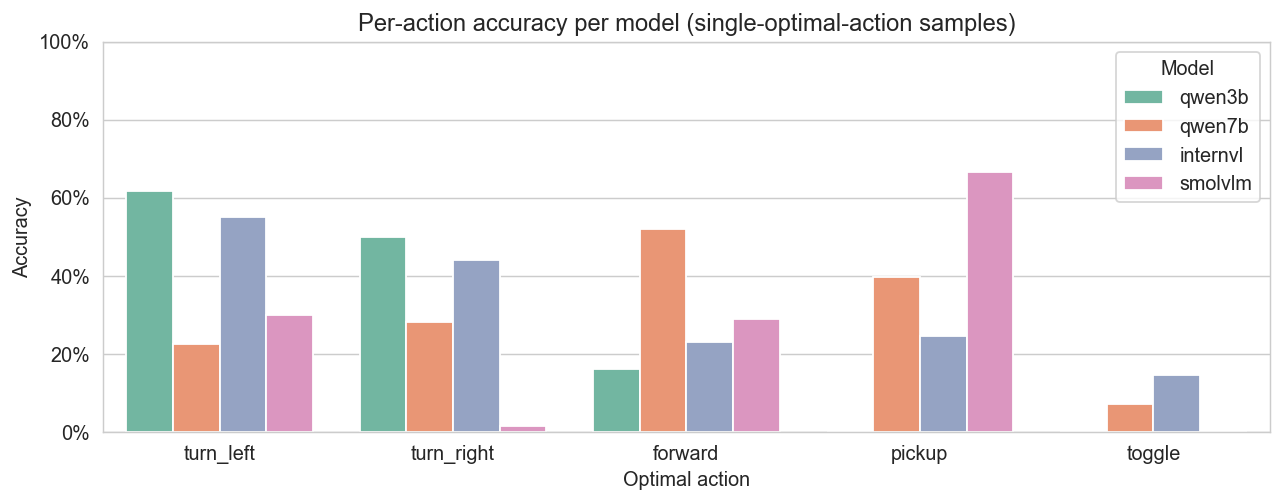

In [70]:
# Per-action accuracy: for each optimal action, what fraction does each model get right?
# Use single-optimal rows only for a clean per-action accuracy
df["predicted_label"] = df["predicted_action"].map(ACTION_MAP)
df_single["optimal_label"] = df_single["optimal_action"].map(ACTION_MAP)

acc_action_model = (
    df_single.groupby(["model", "optimal_label"])["correct"]
    .mean()
    .reset_index()
    .rename(columns={"correct": "accuracy", "optimal_label": "action"})
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=acc_action_model,
    x="action",
    y="accuracy",
    hue="model",
    hue_order=MODEL_ORDER,
    order=ACTION_LABELS,
    palette="Set2",
)
plt.ylim(0, 1)
plt.title("Per-action accuracy per model (single-optimal-action samples)")
plt.ylabel("Accuracy")
plt.xlabel("Optimal action")
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="Model")
plt.tight_layout()
plt.show()


## 4b. Breakdown by prompt variant (per model)

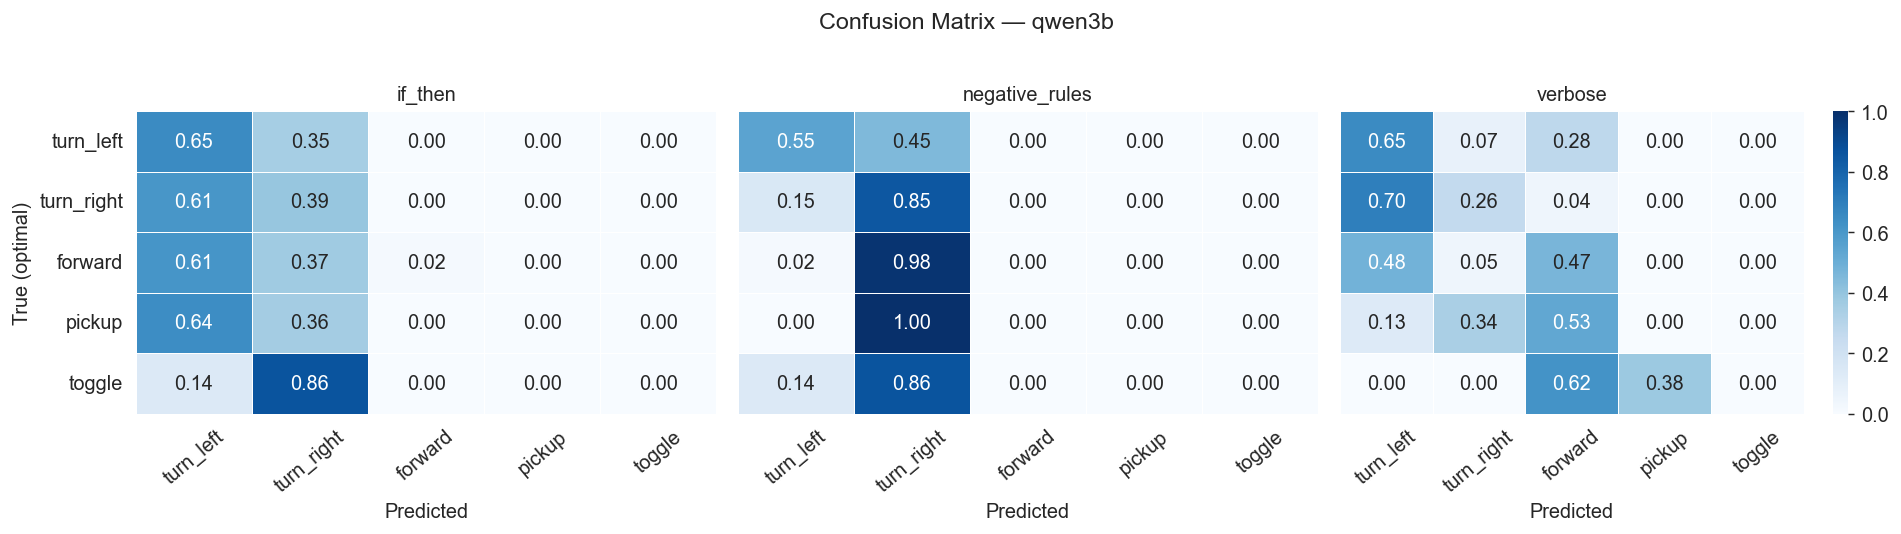

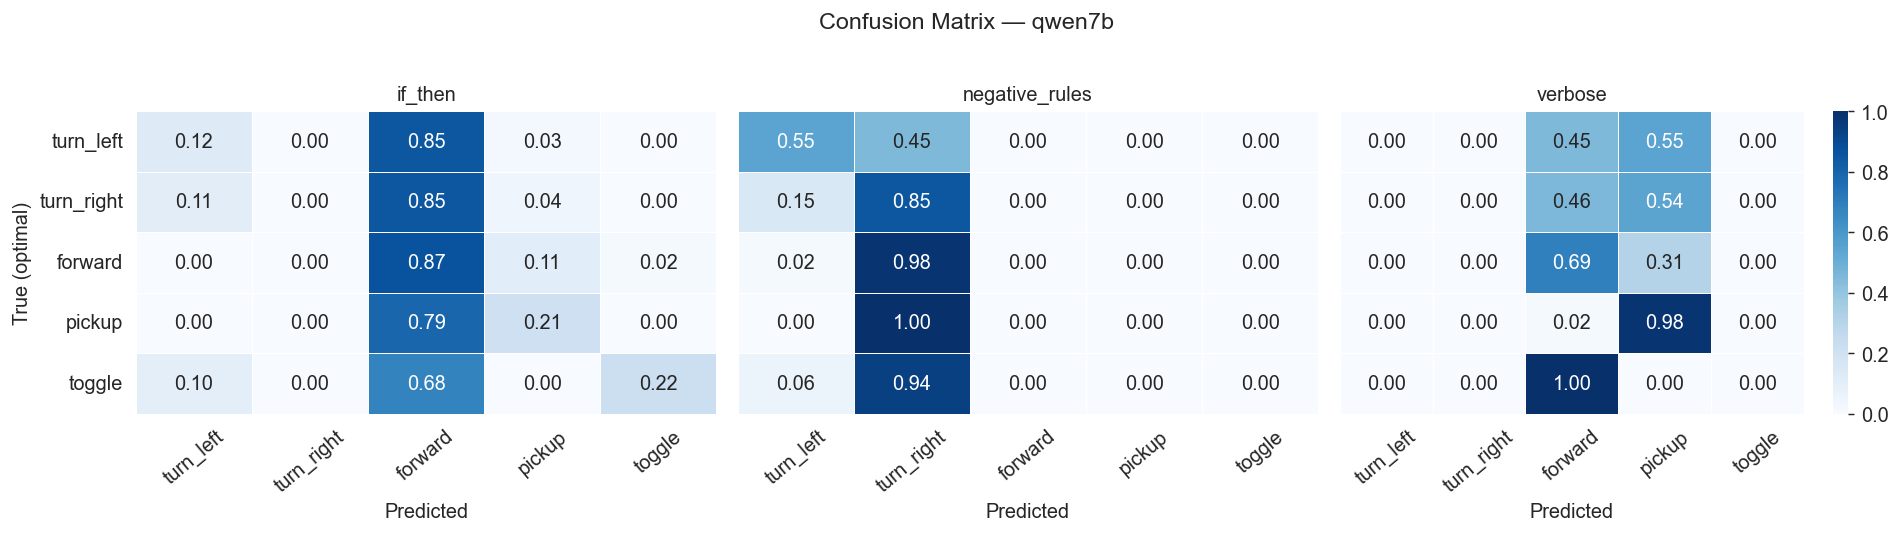

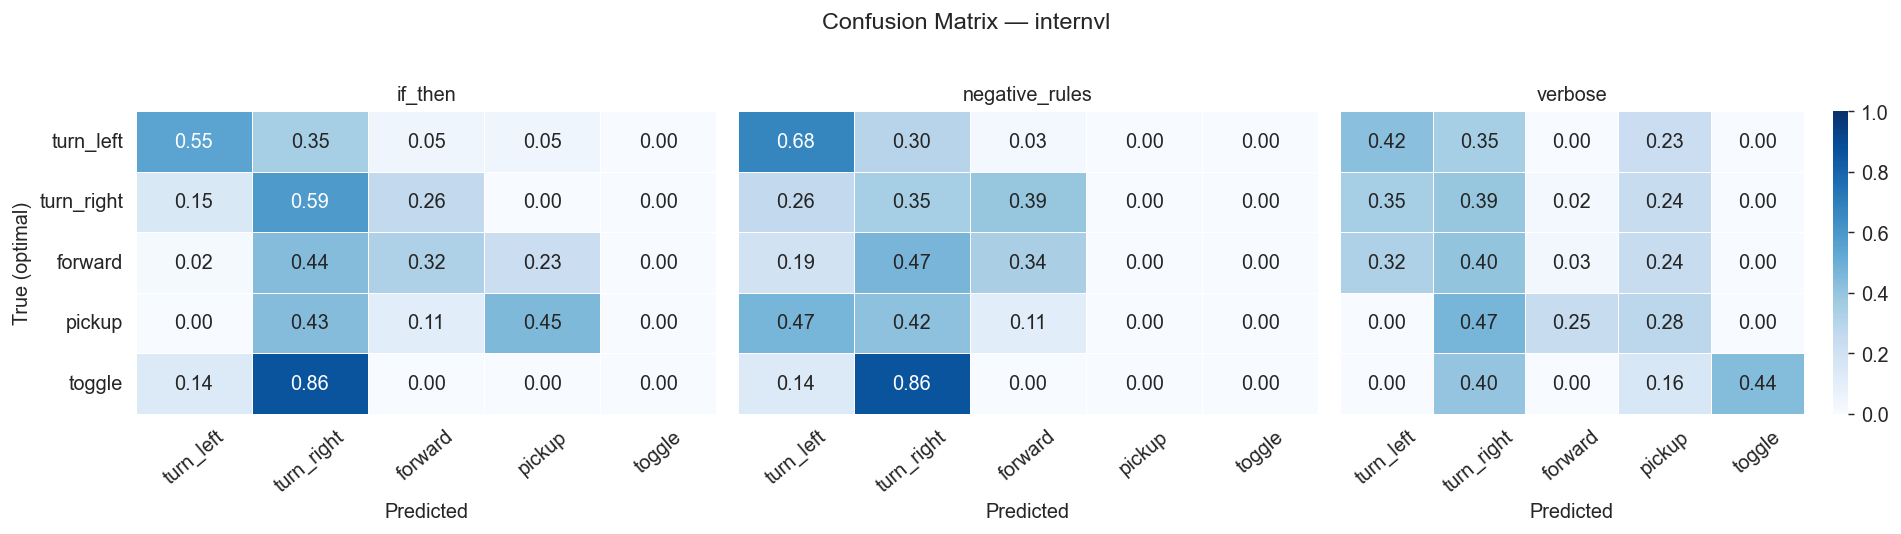

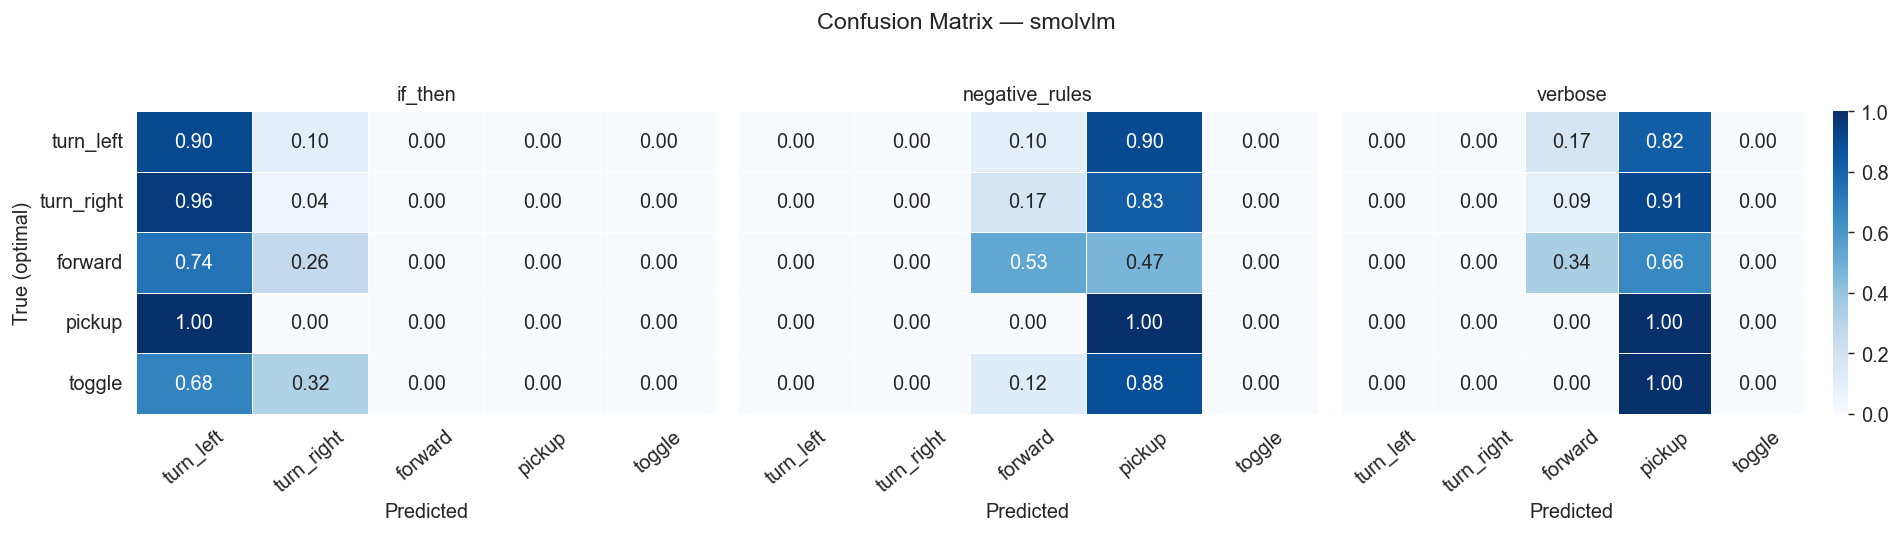

In [71]:
# Confusion matrix per model × variant
# One figure per model; columns = variants; rows = true action; cols = predicted action
import ast
import numpy as np

df["opt_list"] = df["optimal_actions"].apply(ast.literal_eval)
df_single = df[df["opt_list"].apply(len) == 1].copy()
df_single["optimal_action"] = df_single["opt_list"].apply(lambda x: x[0])

ACTION_MAP     = {0: "turn_left", 1: "turn_right", 2: "forward", 3: "pickup", 5: "toggle"}
ACTION_LABELS  = ["turn_left", "turn_right", "forward", "pickup", "toggle"]
ACTION_INDICES = [0, 1, 2, 3, 5]
VARIANT_ORDER  = ["if_then", "negative_rules", "verbose"]

for model in MODEL_ORDER:
    fig, axes = plt.subplots(1, len(VARIANT_ORDER), figsize=(15, 4), sharey=True)
    fig.suptitle(f"Confusion Matrix — {model}", fontsize=13, y=1.02)

    for ax, variant in zip(axes, VARIANT_ORDER):
        sub = df_single[(df_single["model"] == model) & (df_single["variant"] == variant)]
        cm = np.zeros((len(ACTION_INDICES), len(ACTION_INDICES)), dtype=int)
        for _, row in sub.iterrows():
            true_idx = ACTION_INDICES.index(row["optimal_action"])
            pred_val = int(row["predicted_action"])
            if pred_val in ACTION_INDICES:
                cm[ACTION_INDICES.index(pred_val)] if False else None  # no-op
                pred_idx = ACTION_INDICES.index(pred_val)
                cm[true_idx, pred_idx] += 1

        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)

        sns.heatmap(
            cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=ACTION_LABELS, yticklabels=ACTION_LABELS,
            ax=ax, cbar=(variant == VARIANT_ORDER[-1]), linewidths=0.4,
        )
        ax.set_title(variant, fontsize=11)
        ax.set_xlabel("Predicted")
        if variant == VARIANT_ORDER[0]:
            ax.set_ylabel("True (optimal)")
        ax.tick_params(axis="x", rotation=40)
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()


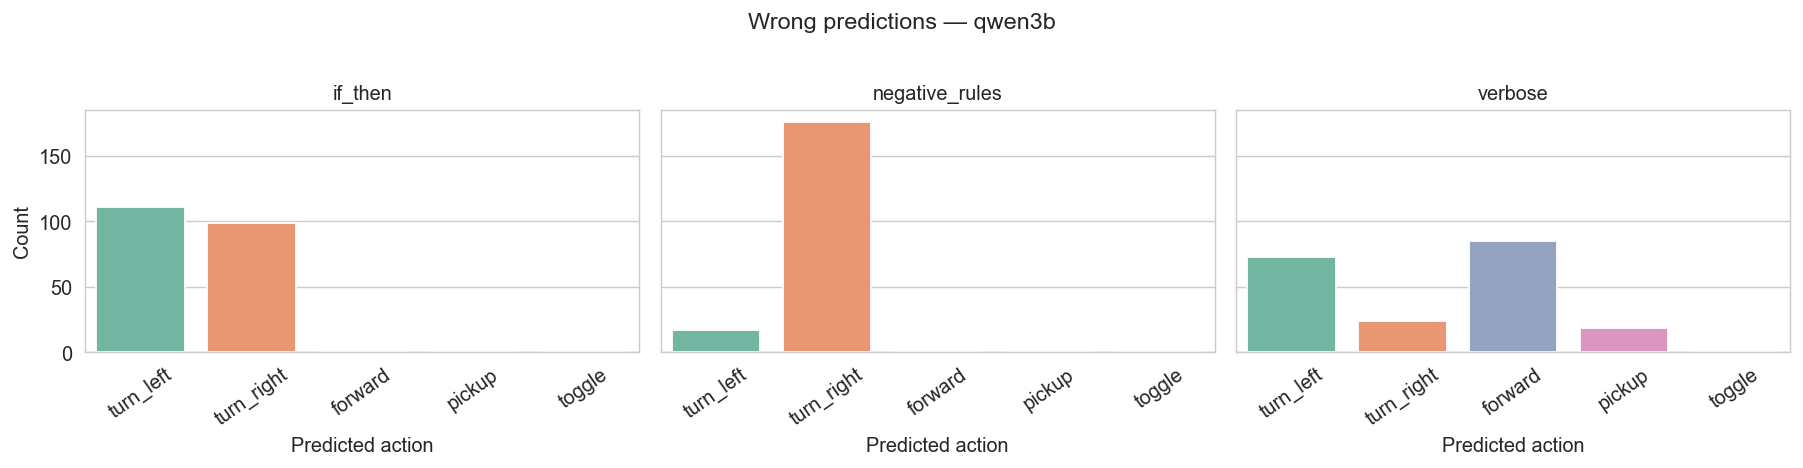

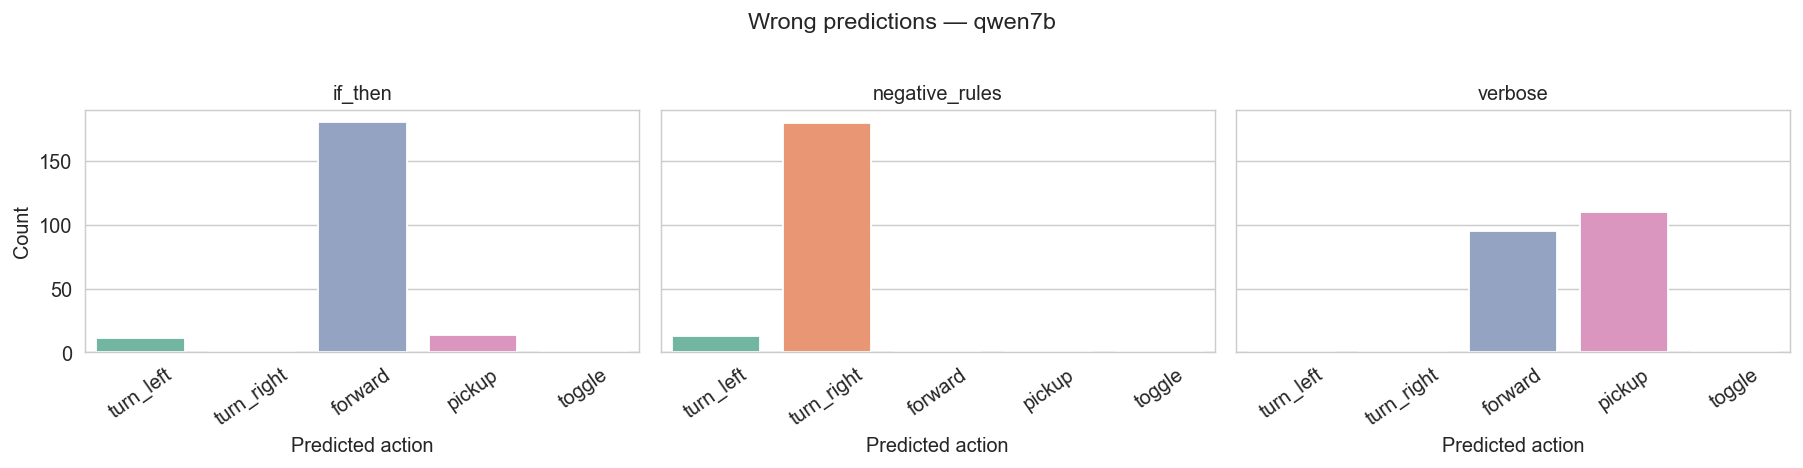

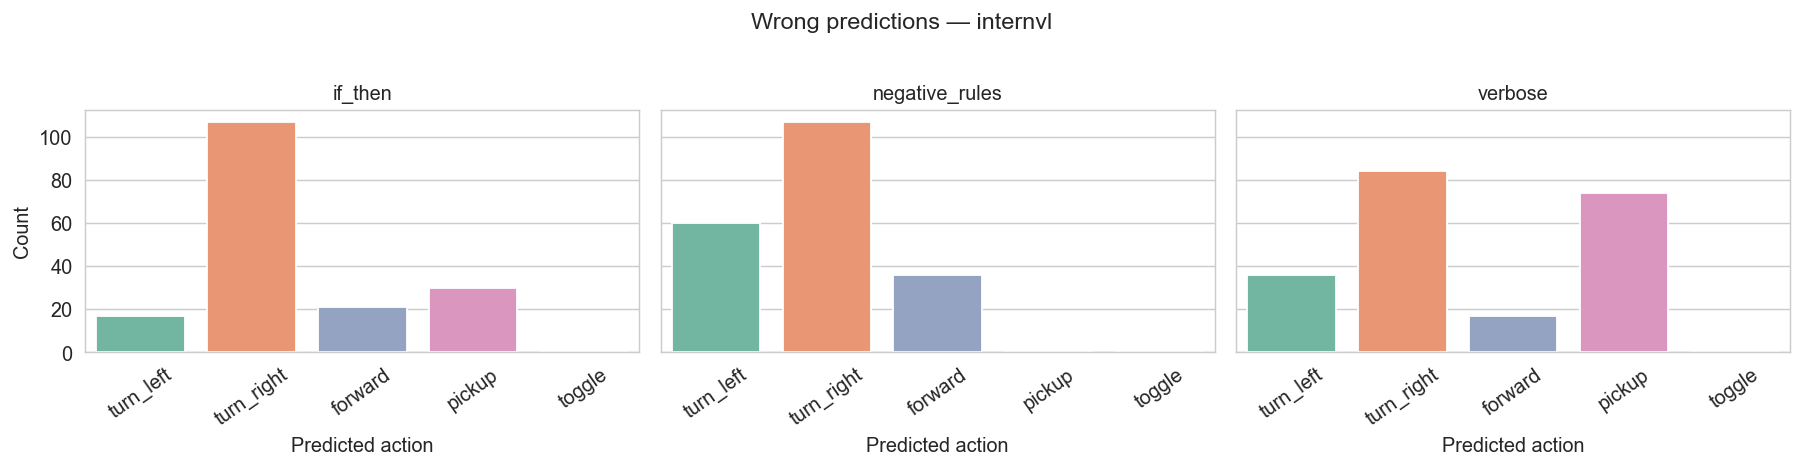

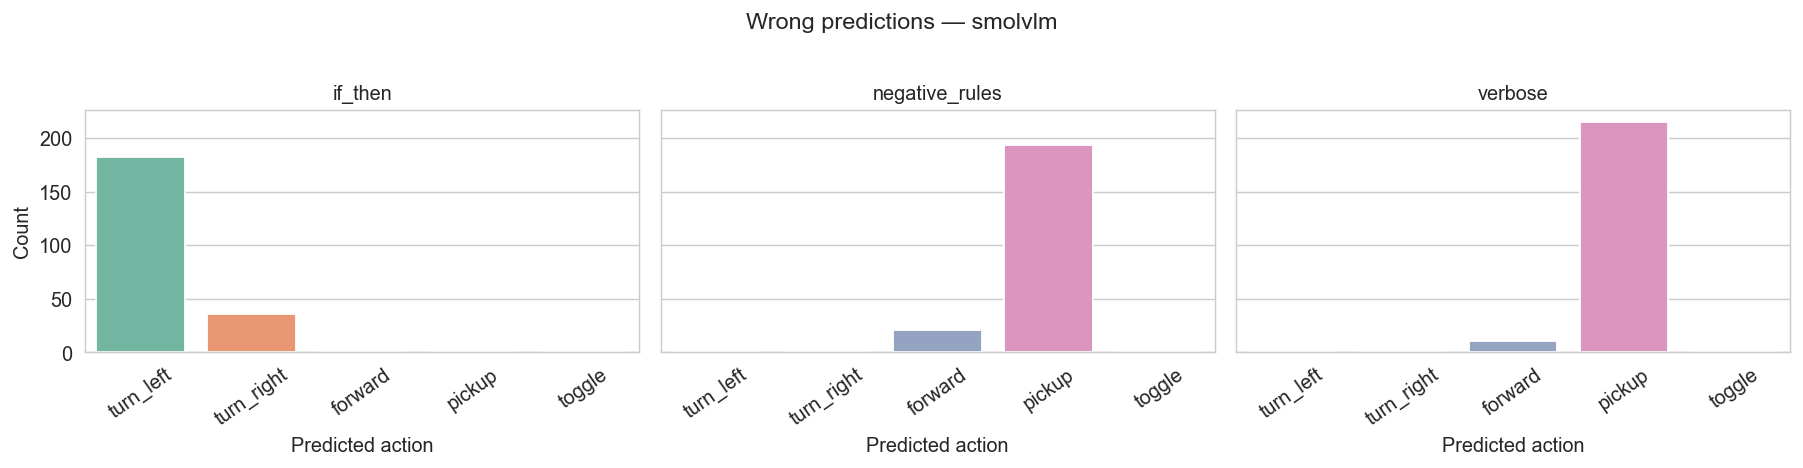

In [72]:
# When wrong, what does each model predict? — broken down by variant
wrong = df[df["correct"] == False].copy()
wrong["predicted_label"] = wrong["predicted_action"].map(ACTION_MAP)

for model in MODEL_ORDER:
    fig, axes = plt.subplots(1, len(VARIANT_ORDER), figsize=(14, 3.5), sharey=True)
    fig.suptitle(f"Wrong predictions — {model}", fontsize=13, y=1.02)

    for ax, variant in zip(axes, VARIANT_ORDER):
        sub = wrong[(wrong["model"] == model) & (wrong["variant"] == variant)]
        counts = sub["predicted_label"].value_counts().reindex(ACTION_LABELS, fill_value=0)
        sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
        ax.set_title(variant, fontsize=11)
        ax.set_xlabel("Predicted action")
        ax.set_ylabel("Count" if variant == VARIANT_ORDER[0] else "")
        ax.tick_params(axis="x", rotation=35)

    plt.tight_layout()
    plt.show()


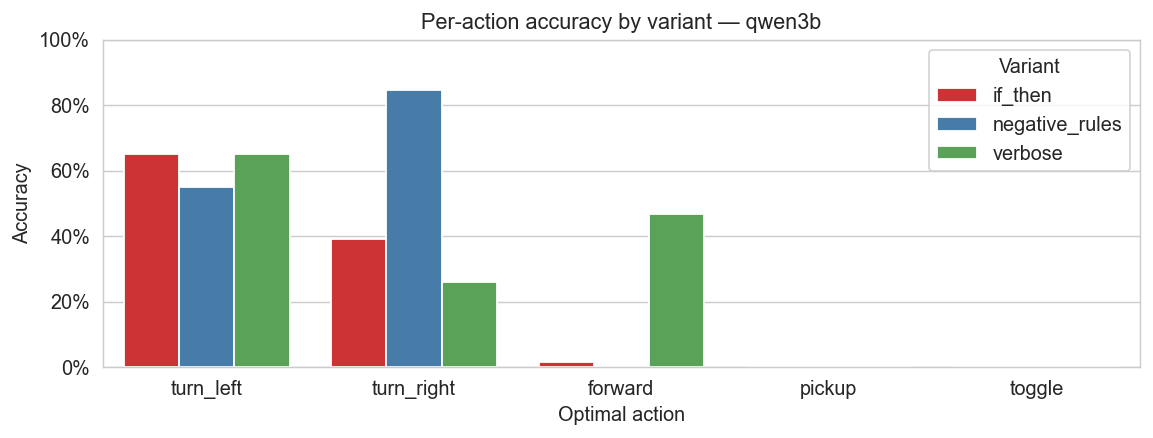

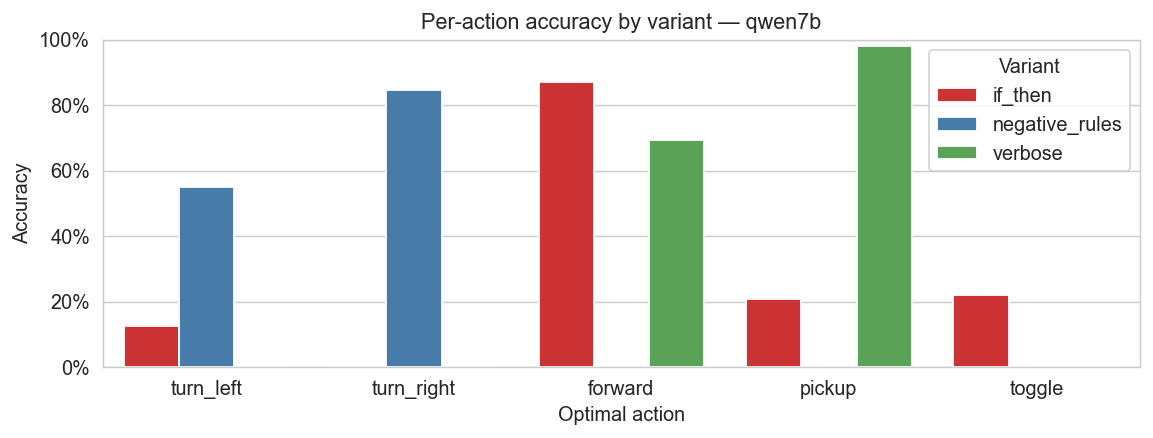

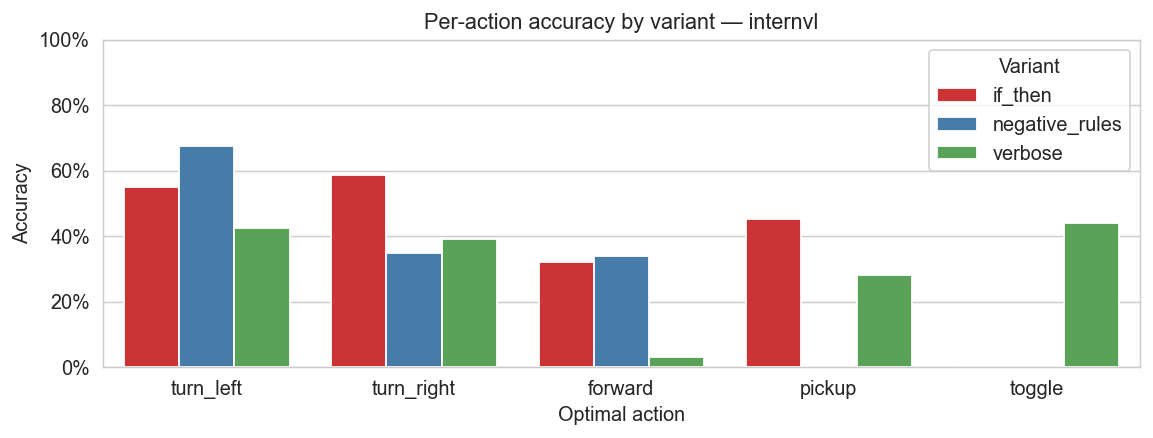

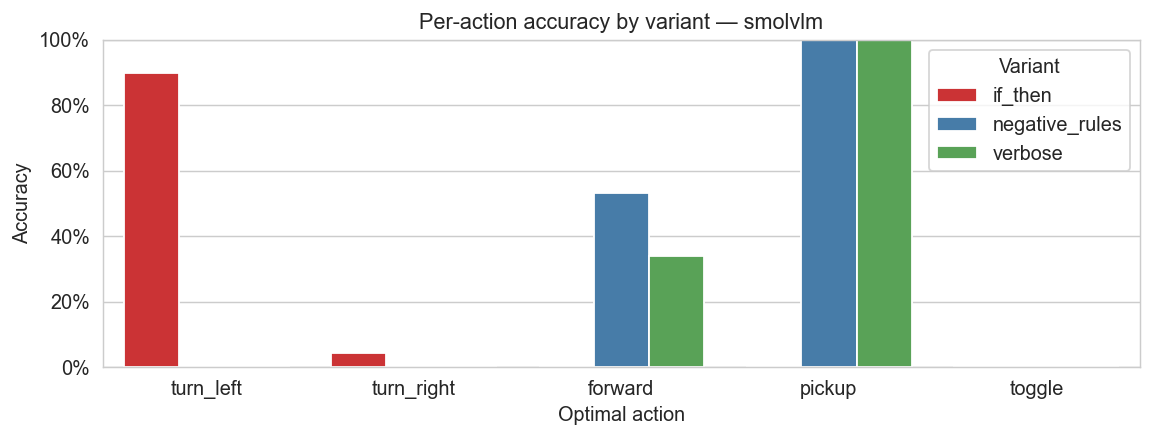

In [73]:
# Per-action accuracy per variant — one figure per model
import matplotlib.ticker as mtick

df_single["optimal_label"] = df_single["optimal_action"].map(ACTION_MAP)

for model in MODEL_ORDER:
    sub = df_single[df_single["model"] == model]
    acc = (
        sub.groupby(["variant", "optimal_label"])["correct"]
        .mean()
        .reset_index()
        .rename(columns={"correct": "accuracy", "optimal_label": "action"})
    )

    plt.figure(figsize=(9, 3.5))
    sns.barplot(
        data=acc, x="action", y="accuracy",
        hue="variant", hue_order=VARIANT_ORDER,
        order=ACTION_LABELS, palette="Set1",
    )
    plt.ylim(0, 1)
    plt.title(f"Per-action accuracy by variant — {model}", fontsize=12)
    plt.ylabel("Accuracy")
    plt.xlabel("Optimal action")
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.legend(title="Variant")
    plt.tight_layout()
    plt.show()


## 5. Latency

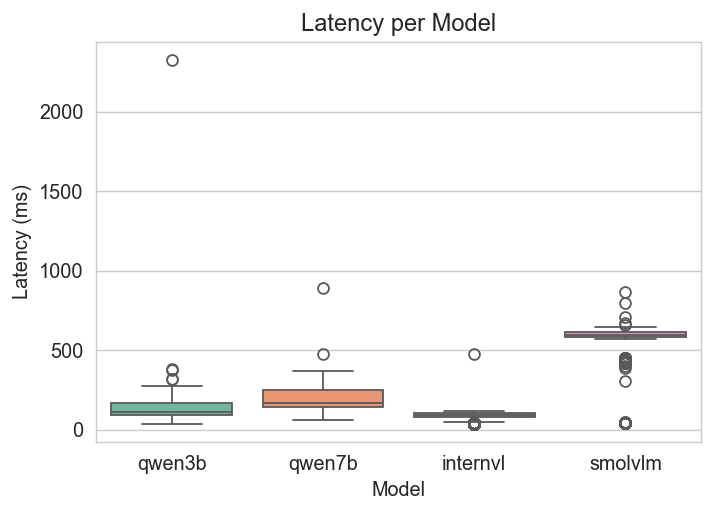

In [74]:
# Compute the Latency per model as a boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x="model", y="latency_ms", data=df, order=MODEL_ORDER, palette="Set2")
plt.title("Latency per Model")
plt.ylabel("Latency (ms)")
plt.xlabel("Model")
plt.show()